In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = "../data/cleaned/"


## 1. Application Train 

Application Train Shape: (307511, 122)


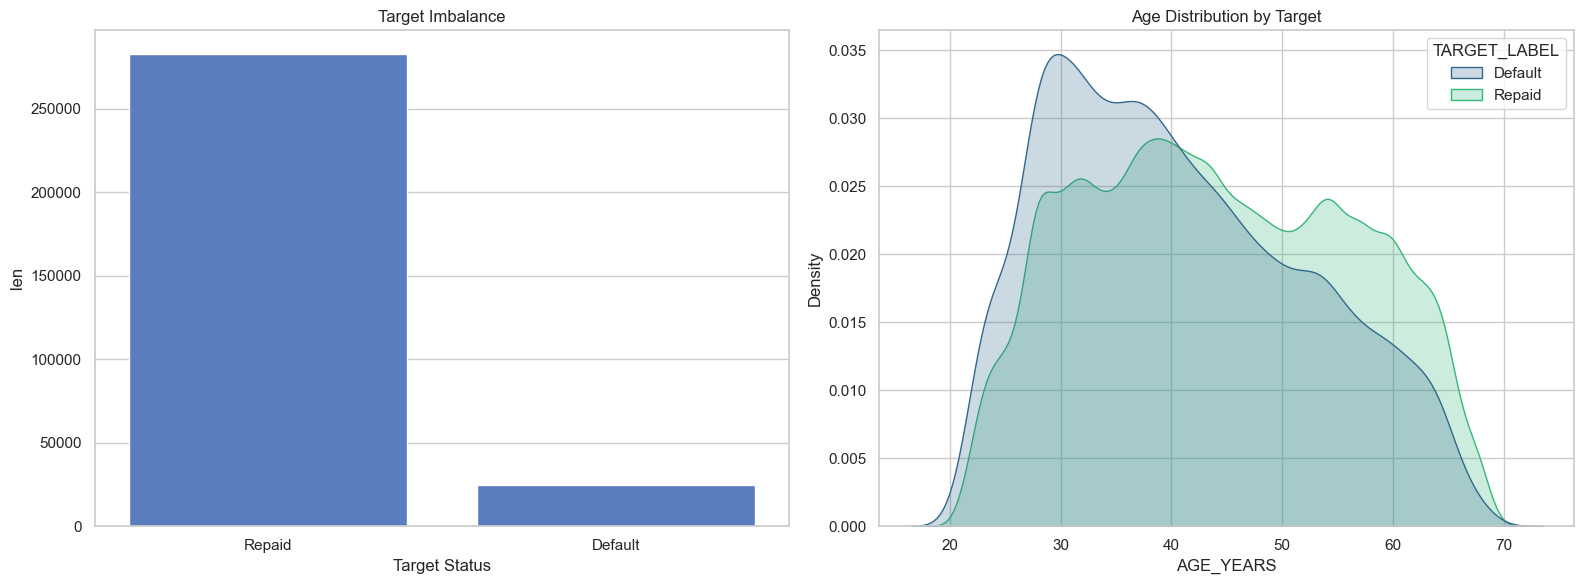

In [ ]:
appl = pl.read_parquet(DATA_DIR + "application_train.parquet")
print(f"Application Train Shape: {appl.shape}")

appl = appl.with_columns(
    pl.when(pl.col("TARGET") == 1)
      .then(pl.lit("Default"))
      .otherwise(pl.lit("Repaid"))
      .alias("TARGET_LABEL")
)

target_dist = appl.group_by("TARGET_LABEL").len().to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Target
sns.barplot(data=target_dist, x="TARGET_LABEL", y="len", ax=axes[0])
axes[0].set_title("Target Imbalance")
axes[0].set_xlabel("Target Status")

# Plot 2: Age vs Target

appl_age = appl.select(["TARGET_LABEL", "DAYS_BIRTH"]).with_columns(
    (pl.col("DAYS_BIRTH") / -365).alias("AGE_YEARS")
).to_pandas()

sns.kdeplot(data=appl_age, x="AGE_YEARS", hue="TARGET_LABEL", fill=True, common_norm=False, ax=axes[1], palette="viridis")
axes[1].set_title("Age Distribution by Target")

plt.tight_layout()
plt.show()


## 2. Bureau 

Bureau Shape: (1716428, 17)


C:\Users\mohak\AppData\Local\Temp\ipykernel_25228\2501948235.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_dist, y="CREDIT_ACTIVE", x="len", ax=axes[0], palette="Blues_d")
C:\Users\mohak\AppData\Local\Temp\ipykernel_25228\2501948235.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_dist, y="CREDIT_TYPE", x="len", ax=axes[1], palette="Greens_d")


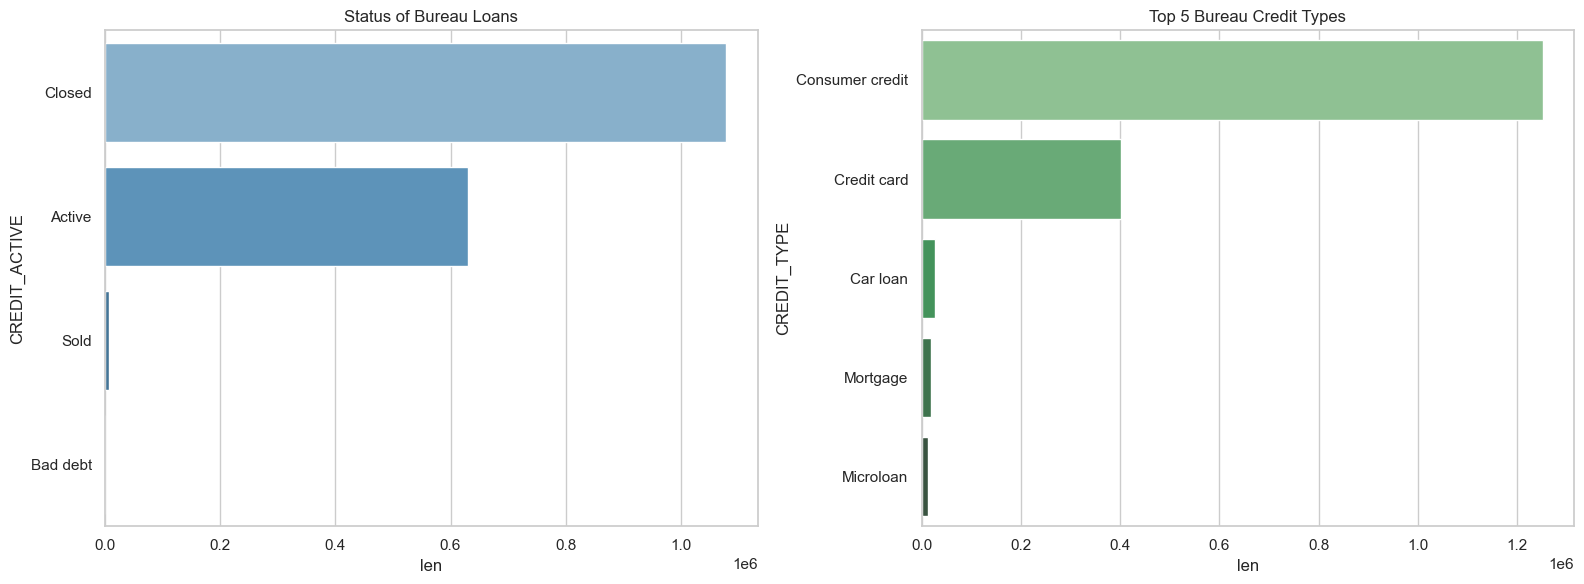

In [4]:
bureau = pl.read_parquet(DATA_DIR + "bureau.parquet")
print(f"Bureau Shape: {bureau.shape}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Active vs Closed
status_dist = bureau.group_by("CREDIT_ACTIVE").len().sort("len", descending=True).to_pandas()
sns.barplot(data=status_dist, y="CREDIT_ACTIVE", x="len", ax=axes[0], palette="Blues_d")
axes[0].set_title("Status of Bureau Loans")

# Plot 2: Top Credit Types
type_dist = bureau.group_by("CREDIT_TYPE").len().sort("len", descending=True).head(5).to_pandas()
sns.barplot(data=type_dist, y="CREDIT_TYPE", x="len", ax=axes[1], palette="Greens_d")
axes[1].set_title("Top 5 Bureau Credit Types")

plt.tight_layout()
plt.show()

## 3. Previous Applications 

Previous Application Shape: (1670214, 37)


C:\Users\mohak\AppData\Local\Temp\ipykernel_25228\2410506052.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_dist, x="NAME_CONTRACT_STATUS", y="len", ax=axes[0], palette="magma")
C:\Users\mohak\AppData\Local\Temp\ipykernel_25228\2410506052.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=purpose_dist, y="NAME_CASH_LOAN_PURPOSE", x="len", ax=axes[1], palette="rocket")


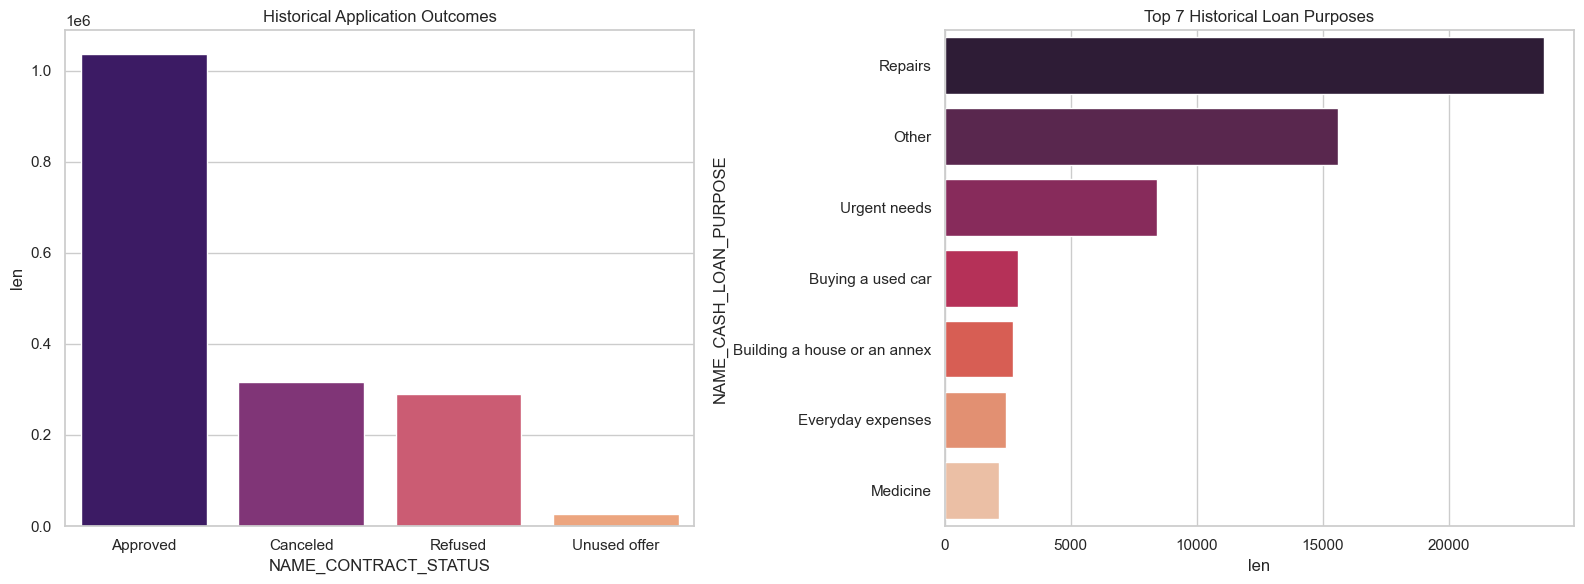

In [5]:
prev = pl.read_parquet(DATA_DIR + "previous_application.parquet")
print(f"Previous Application Shape: {prev.shape}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Contract Status
status_dist = prev.group_by("NAME_CONTRACT_STATUS").len().sort("len", descending=True).to_pandas()
sns.barplot(data=status_dist, x="NAME_CONTRACT_STATUS", y="len", ax=axes[0], palette="magma")
axes[0].set_title("Historical Application Outcomes")

# Plot 2: Loan Purpose (Excluding XNA / XAP)
purpose_dist = prev.filter(
    ~pl.col("NAME_CASH_LOAN_PURPOSE").is_in(["XNA", "XAP"])
).group_by("NAME_CASH_LOAN_PURPOSE").len().sort("len", descending=True).head(7).to_pandas()

sns.barplot(data=purpose_dist, y="NAME_CASH_LOAN_PURPOSE", x="len", ax=axes[1], palette="rocket")
axes[1].set_title("Top 7 Historical Loan Purposes")

plt.tight_layout()
plt.show()

## 4. Installment Payments 

Installments Shape: (13605401, 8)


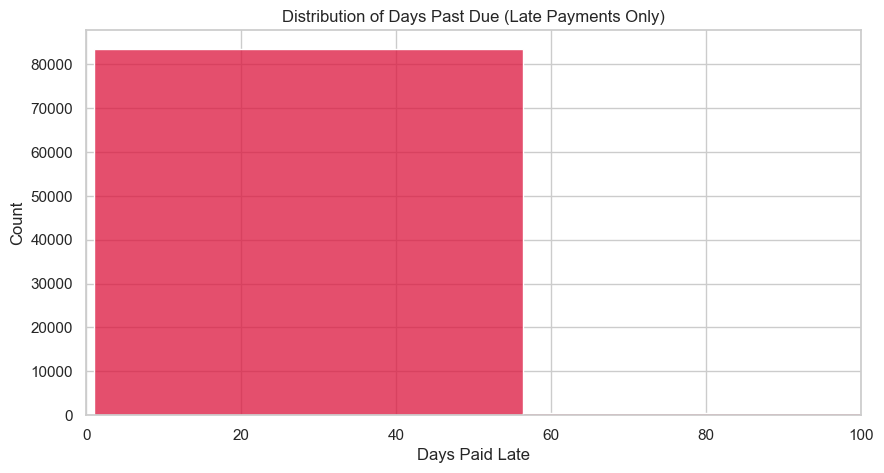

In [6]:
inst = pl.read_parquet(DATA_DIR + "installments_payments.parquet")
print(f"Installments Shape: {inst.shape}")

# Calculate Days Past Due (DPD)
# DAYS_ENTRY_PAYMENT = when they actually paid
# DAYS_INSTALMENT = when they were supposed to pay
# If ENTRY - INSTALMENT > 0, they paid late.
inst = inst.with_columns(
    (pl.col("DAYS_ENTRY_PAYMENT") - pl.col("DAYS_INSTALMENT")).alias("DPD")
)

# Sample the data safely
plot_df = inst.sample(n=min(1000000, inst.height), seed=42)

# Isolate late payments (DPD > 0)
late_payments = plot_df.filter(pl.col("DPD") > 0).to_pandas()

plt.figure(figsize=(10, 5))
sns.histplot(data=late_payments, x="DPD", bins=50, color="crimson")
plt.title("Distribution of Days Past Due (Late Payments Only)")
plt.xlim(0, 100) # Limit to 100 days for visibility
plt.xlabel("Days Paid Late")
plt.show()